In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
import os
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0
)

In [3]:
#state
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [4]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [5]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [6]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

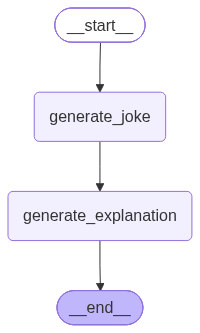

In [7]:
workflow

In [8]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with a lot of *dough* and great *delivery* skills! 🍕😄',
 'explanation': '**Explanation of the Joke**\n\n| Element of the joke | What it literally means | What it figuratively (or humorously) refers to |\n|---------------------|--------------------------|---------------------------------------------------|\n| **Pizza** | A round, baked dish made of dough, sauce, cheese, and toppings. | The “character” in the joke, treated as if it could apply for a job. |\n| **Dough** | The mixture of flour, water, yeast, etc., that forms the base of a pizza crust. | Slang for money (“a lot of dough”). The joke plays on the double meaning: the pizza already has literal dough, and the job posting is looking for someone who brings a lot of money. |\n| **Delivery** | The act of bringing a pizza from a restaurant to a customer’s door. | A common job requirement: the ability to deliver resu

In [9]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with a lot of *dough* and great *delivery* skills! 🍕😄', 'explanation': '**Explanation of the Joke**\n\n| Element of the joke | What it literally means | What it figuratively (or humorously) refers to |\n|---------------------|--------------------------|---------------------------------------------------|\n| **Pizza** | A round, baked dish made of dough, sauce, cheese, and toppings. | The “character” in the joke, treated as if it could apply for a job. |\n| **Dough** | The mixture of flour, water, yeast, etc., that forms the base of a pizza crust. | Slang for money (“a lot of dough”). The joke plays on the double meaning: the pizza already has literal dough, and the job posting is looking for someone who brings a lot of money. |\n| **Delivery** | The act of bringing a pizza from a restaurant to a customer’s door. | A common job requirement: the abil

In [10]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with a lot of *dough* and great *delivery* skills! 🍕😄', 'explanation': '**Explanation of the Joke**\n\n| Element of the joke | What it literally means | What it figuratively (or humorously) refers to |\n|---------------------|--------------------------|---------------------------------------------------|\n| **Pizza** | A round, baked dish made of dough, sauce, cheese, and toppings. | The “character” in the joke, treated as if it could apply for a job. |\n| **Dough** | The mixture of flour, water, yeast, etc., that forms the base of a pizza crust. | Slang for money (“a lot of dough”). The joke plays on the double meaning: the pizza already has literal dough, and the job posting is looking for someone who brings a lot of money. |\n| **Delivery** | The act of bringing a pizza from a restaurant to a customer’s door. | A common job requirement: the abi

In [11]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti get a promotion?\n\nBecause it *pasta* way to the top! 🍝😄',
 'explanation': '**Joke:**  \n*Why did the spaghetti get a promotion?*  \n*Because it **pasta** way to the top!* 🍝😄  \n\n---\n\n## Why it’s funny – the mechanics of the joke  \n\n| Element | What it is | How it works in the joke |\n|---------|------------|--------------------------|\n| **Setup** | “Why did the spaghetti get a promotion?” – a classic “why‑question” that makes the listener expect a workplace‑related punch‑line. | It frames the spaghetti as an employee, priming us to think about work performance, ambition, or office politics. |\n| **Punchline** | “Because it *pasta* way to the **pasta** way to the top!” – a play on the phrase “*passed* the way to the top.” | The humor comes from a **pun** (a word that sounds like another word but has a different meaning). Here “pasta” (the Italian staple that includes spaghetti) sounds exactly like “passed.” |\n| **Wordplay** | *

In [ ]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with a lot of *dough* and great *delivery* skills! 🍕😄', 'explanation': '**Explanation of the Joke**\n\n| Element of the joke | What it literally means | What it figuratively (or humorously) refers to |\n|---------------------|--------------------------|---------------------------------------------------|\n| **Pizza** | A round, baked dish made of dough, sauce, cheese, and toppings. | The “character” in the joke, treated as if it could apply for a job. |\n| **Dough** | The mixture of flour, water, yeast, etc., that forms the base of a pizza crust. | Slang for money (“a lot of dough”). The joke plays on the double meaning: the pizza already has literal dough, and the job posting is looking for someone who brings a lot of money. |\n| **Delivery** | The act of bringing a pizza from a restaurant to a customer’s door. | A common job requirement: the abil

In [13]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with a lot of *dough* and great *delivery* skills! 🍕😄', 'explanation': '**Explanation of the Joke**\n\n| Element of the joke | What it literally means | What it figuratively (or humorously) refers to |\n|---------------------|--------------------------|---------------------------------------------------|\n| **Pizza** | A round, baked dish made of dough, sauce, cheese, and toppings. | The “character” in the joke, treated as if it could apply for a job. |\n| **Dough** | The mixture of flour, water, yeast, etc., that forms the base of a pizza crust. | Slang for money (“a lot of dough”). The joke plays on the double meaning: the pizza already has literal dough, and the job posting is looking for someone who brings a lot of money. |\n| **Delivery** | The act of bringing a pizza from a restaurant to a customer’s door. | A common job requirement: the abi

### Time Travel

In [15]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1b4da0-a2d1-6850-8001-419ae8dbcddf"}})

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with a lot of *dough* and great *delivery* skills! 🍕😄'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1b4da0-a2d1-6850-8001-419ae8dbcddf'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-09-20T09:59:59.179359+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b4da0-9b12-602a-8000-8dc23f9e50d8'}}, tasks=(PregelTask(id='0cf27611-1365-c354-07d1-046e8314b8df', name='generate_explanation', path=('__pregel_pull', 'generate_explanation'), error=None, interrupts=(), state=None, result={'explanation': '**Explanation of the Joke**\n\n| Element of the joke | What it literally means | What it figuratively (or humorously) refers to |\n|---------------------|--------------------------|---------------------------------------------------|\n|

In [ ]:
# The first argument is the input to the workflow.
# None means -> I don't want to give new input. Continue using the existing workflow state.
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1b4da0-a2d1-6850-8001-419ae8dbcddf"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with a lot of *dough* and great *delivery* skills! 🍕😄',
 'explanation': '**Explanation of the Joke**\n\n| Element of the joke | What it literally means | What it figuratively (or humorously) refers to |\n|---------------------|--------------------------|---------------------------------------------------|\n| **Pizza** | A round, baked dish made of dough, sauce, cheese, and toppings. | The “character” in the joke, treated as if it could apply for a job. |\n| **Dough** | The mixture of flour, water, yeast, etc., that forms the base of a pizza crust. | Slang for money (“a lot of dough”). The joke plays on the double meaning: the pizza already has literal dough, and the job posting is looking for someone who brings a lot of money. |\n| **Delivery** | The act of bringing a pizza from a restaurant to a customer’s door. | A common job requirement: the ability to deliver resu

In [17]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with a lot of *dough* and great *delivery* skills! 🍕😄', 'explanation': '**Explanation of the Joke**\n\n| Element of the joke | What it literally means | What it figuratively (or humorously) refers to |\n|---------------------|--------------------------|---------------------------------------------------|\n| **Pizza** | A round, baked dish made of dough, sauce, cheese, and toppings. | The “character” in the joke, treated as if it could apply for a job. |\n| **Dough** | The mixture of flour, water, yeast, etc., that forms the base of a pizza crust. | Slang for money (“a lot of dough”). The joke plays on the double meaning: the pizza already has literal dough, and the job posting is looking for someone who brings a lot of money. |\n| **Delivery** | The act of bringing a pizza from a restaurant to a customer’s door. | A common job requirement: the abi

### Updating State

In [18]:
# update the state on the particulat checkpoint 
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1b4da0-a2d1-6850-8001-419ae8dbcddf", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1b4de9-521d-6328-8002-8c524ff4d7fe'}}

In [19]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with a lot of *dough* and great *delivery* skills! 🍕😄'}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b4de9-521d-6328-8002-8c524ff4d7fe'}}, metadata={'source': 'update', 'step': 2, 'parents': {}}, created_at='2026-09-20T10:32:30.295602+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1b4da0-a2d1-6850-8001-419ae8dbcddf'}}, tasks=(PregelTask(id='cebde933-ec72-7b27-56d8-7818f54c8020', name='generate_explanation', path=('__pregel_pull', 'generate_explanation'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it heard the company was looking for someone with a lot of *dough* and great *delivery* skills! 🍕😄', 'expla

### Fault tolerance(The ability of a workflow to recover from failures without losing its previous progress)

In [2]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [3]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str

In [ ]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(1000)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

In [5]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [7]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed


In [8]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...

✅ Final State: {'input': 'start', 'step1': 'done'}
